# ReturnGuard — Proof-of-Concept Analysis
**MGSC 661 Group Project.** Predicting which e-commerce purchases will be returned, using the ASOS GraphReturns dataset.

## Workflow
```
1. Load      6 pickle files (events, customers, products × train/test)
2. Clean     drop duplicate purchases and a duplicated column
3. Merge     attach customer + product features to each purchase
4. Explore   size, return rate, coverage of the merge
5. Leakage   show that the provided return-rate features contain the answer
6. Features  build leak-free return history from the EARLIER period only
7. Model     logistic regression; evaluate on customers the model never saw
8. Results   AUC, return rate by risk group, main drivers
```

**Data:** download the zip from https://osf.io/c793h/ and put the six `.p` files in a folder called `data/` next to this notebook.
Source paper: McGowan et al. (2022), *A Dataset for Learning Graph Representations to Predict Customer Returns in Fashion Retail* (arXiv:2302.14096).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score

DATA = "data/"
SEED = 0
pd.set_option("display.max_columns", 50)

## 1–2. Load and clean

In [2]:
def load(split):
    ev = pd.read_pickle(f"{DATA}event_table_{split}.p")
    cu = pd.read_pickle(f"{DATA}customer_nodes_{split}.p")
    pr = pd.read_pickle(f"{DATA}product_nodes_{split}.p")
    n_dup = ev.duplicated().sum()
    ev = ev.drop_duplicates()
    # 'return_code_D' appears twice in both feature tables; keep the first copy
    cu = cu.loc[:, ~cu.columns.duplicated()]
    pr = pr.loc[:, ~pr.columns.duplicated()]
    print(f"{split:8s}: {len(ev):,} purchases ({n_dup:,} duplicates dropped), "
          f"{len(cu):,} customers, {len(pr):,} product variants")
    return ev, cu, pr

ev_tr, cu_tr, pr_tr = load("training")   # Sept–Oct 2021
ev_te, cu_te, pr_te = load("testing")    # Oct–Nov 2021

training: 1,362,582 purchases (6,551 duplicates dropped), 777,001 customers, 411,495 product variants


testing : 1,453,143 purchases (7,223 duplicates dropped), 825,598 customers, 411,544 product variants


In [3]:
print("Event table columns:", list(ev_tr.columns))
print("\nCustomer table columns:", list(cu_tr.columns))
print("\nProduct table columns:", list(pr_tr.columns))

Event table columns: ['hash(variantID)', 'hash(customerId)', 'isReturned']

Customer table columns: ['hash(customerId)', 'yearOfBirth', 'isMale', 'shippingCountry', 'premier', 'salesPerCustomer', 'returnsPerCustomer', 'customerReturnRate', 'customerId_level_return_code_A', 'customerId_level_return_code_B', 'customerId_level_return_code_C', 'customerId_level_return_code_D', 'customerId_level_return_code_E', 'customerId_level_return_code_F', 'customerId_level_return_code_G', 'customerId_level_return_code_H', 'customerId_level_return_code_I', 'customerId_level_return_code_J', 'customerId_level_return_code_K', 'customerId_level_return_code_L', 'Country_A', 'Country_B', 'Country_C', 'Country_D', 'Country_E', 'Country_F', 'Country_G', 'Country_H', 'Country_I']

Product table columns: ['hash(variantID)', 'hash(productID)', 'productType', 'hash(supplierRef)', 'brandDesc', 'avgGbpPrice', 'avgDiscountValue', 'salesPerProduct', 'returnsPerProduct', 'productReturnRate', 'variantID_level_return_cod

## 3–4. Merge and explore

In [4]:
KEEP_CU = ["hash(customerId)", "yearOfBirth", "isMale", "premier", "shippingCountry",
           "salesPerCustomer", "customerReturnRate"]
KEEP_PR = ["hash(variantID)", "productType", "brandDesc", "avgGbpPrice", "avgDiscountValue",
           "salesPerProduct", "productReturnRate"]

def merge(ev, cu, pr):
    # return-reason columns are deliberately not carried over (see Section 5)
    cu = cu[KEEP_CU + [c for c in cu.columns if c.startswith("Country_")]]
    pr = pr[KEEP_PR + [c for c in pr.columns if c.startswith(("Brand_", "productType_"))]]
    return (ev.merge(cu, on="hash(customerId)", how="inner")
              .merge(pr, on="hash(variantID)", how="inner"))

df_tr = merge(ev_tr, cu_tr, pr_tr)
df_te = merge(ev_te, cu_te, pr_te)

# keep only what later cells need, to save memory
same = cu_tr[["hash(customerId)", "salesPerCustomer"]].merge(
    cu_te[["hash(customerId)", "salesPerCustomer"]], on="hash(customerId)", suffixes=("_tr", "_te"))
all_customers_return = (cu_tr.returnsPerCustomer >= 1).all()
del cu_tr, pr_tr, cu_te, pr_te
import gc; gc.collect()

for name, ev, df in [("training", ev_tr, df_tr), ("testing", ev_te, df_te)]:
    print(f"{name:8s}: {len(df):,} of {len(ev):,} purchases have both customer and product "
          f"features ({len(df)/len(ev):.0%}); return rate {df.isReturned.mean():.1%}")

print("\nEvery customer has at least one return:", all_customers_return)

training: 844,405 of 1,362,582 purchases have both customer and product features (62%); return rate 54.8%
testing : 955,792 of 1,453,143 purchases have both customer and product features (66%); return rate 53.6%

Every customer has at least one return: True


**Notes.**
- About 55% of purchases are returned. This is **not** ASOS's real return rate: the dataset only includes customers with at least one return. We frame the question as *"among customers who return items, which purchases come back?"*
- Some purchases have no matching product row, so the merge keeps roughly 60–65% of them. That still leaves ~0.85–0.95M purchases per period.
- Brand, product type and country are anonymised (A–K), so insights are stated as patterns rather than named categories.

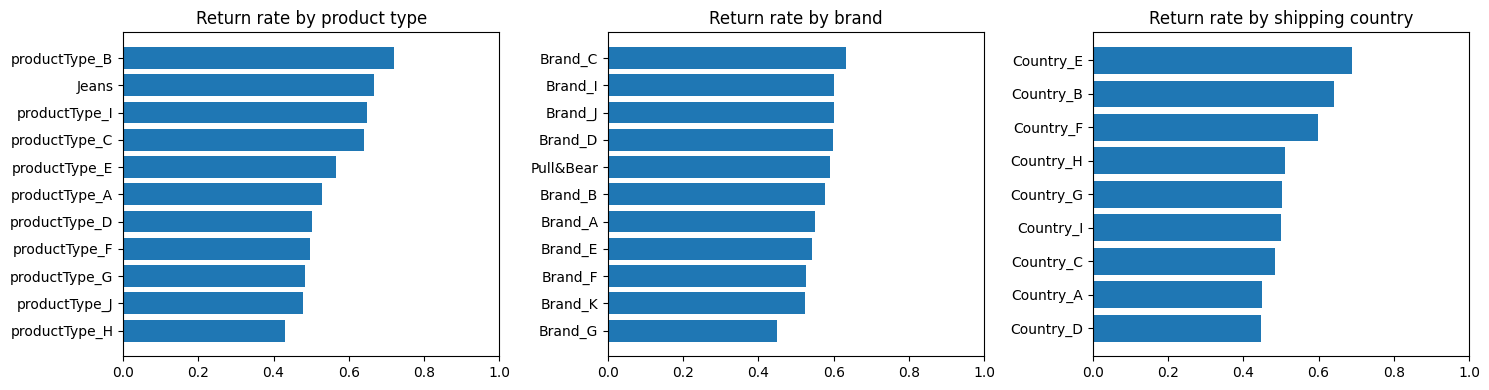

avgGbpPrice
(1.729, 11.28]    0.393
(11.28, 17.07]    0.519
(17.07, 23.9]     0.568
(23.9, 33.91]     0.607
(33.91, 420.0]    0.656
Name: isReturned, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in [(axes[0], "productType", "Product type"),
                       (axes[1], "brandDesc", "Brand"),
                       (axes[2], "shippingCountry", "Shipping country")]:
    rates = df_tr.groupby(col).isReturned.mean().sort_values()
    ax.barh(rates.index, rates.values)
    ax.set_title(f"Return rate by {label.lower()}")
    ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()

price_band = pd.qcut(df_tr.avgGbpPrice, 5)
print(df_tr.groupby(price_band, observed=True).isReturned.mean().round(3))

## 5. Leakage check

The customer and product tables include return rates, return counts and the mix of **return reasons**. These are computed separately for each period, so a test customer's return rate appears to include the very purchases we are trying to predict. Evidence:
- The same customer has different numbers in the training and testing tables (the summaries are period-specific).
- Return reasons only exist *because* an item was returned.

Below we show how much these features inflate performance.

In [6]:
print(f"Customers in both tables: {len(same):,}; "
      f"salesPerCustomer identical in both periods: {(same.salesPerCustomer_tr == same.salesPerCustomer_te).mean():.1%}")

Customers in both tables: 183,498; salesPerCustomer identical in both periods: 4.8%


In [7]:
SAFE = (["yearOfBirth", "isMale", "premier", "avgGbpPrice", "avgDiscountValue"]
        + [c for c in df_te.columns if c.startswith(("Country_", "Brand_", "productType_"))])
LEAKY = ["customerReturnRate", "productReturnRate", "salesPerCustomer", "salesPerProduct"]

def fit_auc(train, test, cols, n=300_000):
    train = train.sample(min(n, len(train)), random_state=SEED)
    mu, sd = train[cols].mean(), train[cols].std().replace(0, 1)
    m = LogisticRegression(max_iter=1000).fit((train[cols] - mu) / sd, train.isReturned)
    p = m.predict_proba((test[cols] - mu) / sd)[:, 1]
    return roc_auc_score(test.isReturned, p), m, mu, sd, p

rows = []
for label, cols in [("Customer return rate only", ["customerReturnRate"]),
                    ("Product return rate only", ["productReturnRate"]),
                    ("Safe + leaky aggregates", SAFE + LEAKY),
                    ("Safe features only", SAFE)]:
    auc = fit_auc(df_tr, df_te, cols)[0]
    rows.append((label, round(auc, 3)))
pd.DataFrame(rows, columns=["Features", "Test AUC"])

,Features,Test AUC
0,Customer return rate only,0.808
1,Product return rate only,0.722
2,Safe + leaky aggregates,0.842
3,Safe features only,0.666


**Takeaway:** a naive model reaches AUC ≈ 0.84, but it relies on information that would not exist at checkout. We drop the period-specific return rates and all return-reason columns.

## 6. Leak-free features: return history from the earlier period

At checkout in Oct–Nov, a retailer *would* know each customer's and product's return history from Sept–Oct. We compute that from the training-period purchases and attach it to the testing-period purchases. Customers or products not seen before get the average rate plus a "first time" flag.

In [8]:
base = ev_tr.isReturned.mean()
cust_hist = ev_tr.groupby("hash(customerId)").isReturned.agg(prior_cust_buys="count", prior_cust_rate="mean").reset_index()
prod_hist = ev_tr.groupby("hash(variantID)").isReturned.agg(prior_prod_buys="count", prior_prod_rate="mean").reset_index()

df = (df_te.merge(cust_hist, on="hash(customerId)", how="left")
           .merge(prod_hist, on="hash(variantID)", how="left"))
for who in ["cust", "prod"]:
    df[f"prior_{who}_seen"] = df[f"prior_{who}_rate"].notna().astype(int)
    df[f"prior_{who}_rate"] = df[f"prior_{who}_rate"].fillna(base)
    df[f"prior_{who}_buys"] = df[f"prior_{who}_buys"].fillna(0)

HIST = ["prior_cust_rate", "prior_cust_buys", "prior_cust_seen",
        "prior_prod_rate", "prior_prod_buys", "prior_prod_seen"]
print(f"Customers seen in the earlier period: {df.prior_cust_seen.mean():.0%} of purchases")
print(f"Products seen in the earlier period:  {df.prior_prod_seen.mean():.0%} of purchases")

Customers seen in the earlier period: 28% of purchases
Products seen in the earlier period:  74% of purchases


## 7. Model

We fit on 70% of testing-period **customers** and evaluate on the other 30%, so no customer appears on both sides of the split.

In [9]:
tr_idx, ho_idx = next(GroupShuffleSplit(1, test_size=0.3, random_state=SEED)
                      .split(df, groups=df["hash(customerId)"]))
train, hold = df.iloc[tr_idx], df.iloc[ho_idx].copy()

auc_safe = fit_auc(train, hold, SAFE)[0]
auc_full, model, mu, sd, hold["p"] = fit_auc(train, hold, SAFE + HIST)
print(f"Safe features only:              AUC {auc_safe:.3f}")
print(f"Safe + leak-free return history: AUC {auc_full:.3f}")

Safe features only:              AUC 0.665
Safe + leak-free return history: AUC 0.683


## 8. Results: return rate by predicted risk group

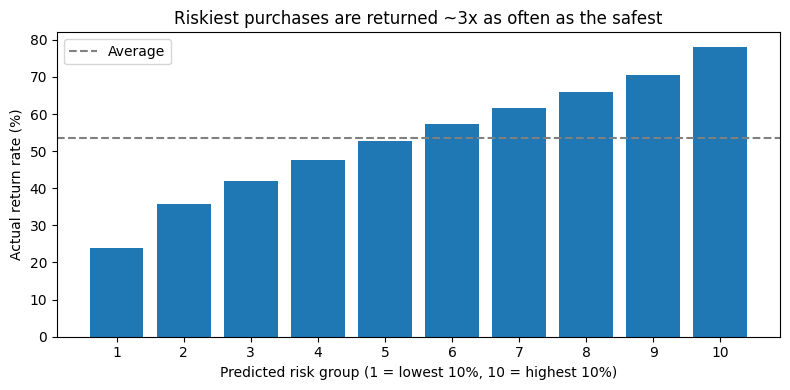

risk_group
1     24.0
2     35.9
3     41.9
4     47.7
5     52.7
6     57.4
7     61.5
8     65.9
9     70.6
10    78.1


In [10]:
hold["risk_group"] = pd.qcut(hold.p.rank(method="first"), 10, labels=range(1, 11))
dec = hold.groupby("risk_group", observed=True).isReturned.mean()

plt.figure(figsize=(8, 4))
plt.bar(dec.index.astype(str), dec.values * 100)
plt.axhline(hold.isReturned.mean() * 100, ls="--", c="grey", label="Average")
plt.xlabel("Predicted risk group (1 = lowest 10%, 10 = highest 10%)")
plt.ylabel("Actual return rate (%)")
plt.title("Riskiest purchases are returned ~3x as often as the safest")
plt.legend(); plt.tight_layout(); plt.show()
print((dec * 100).round(1).to_string())

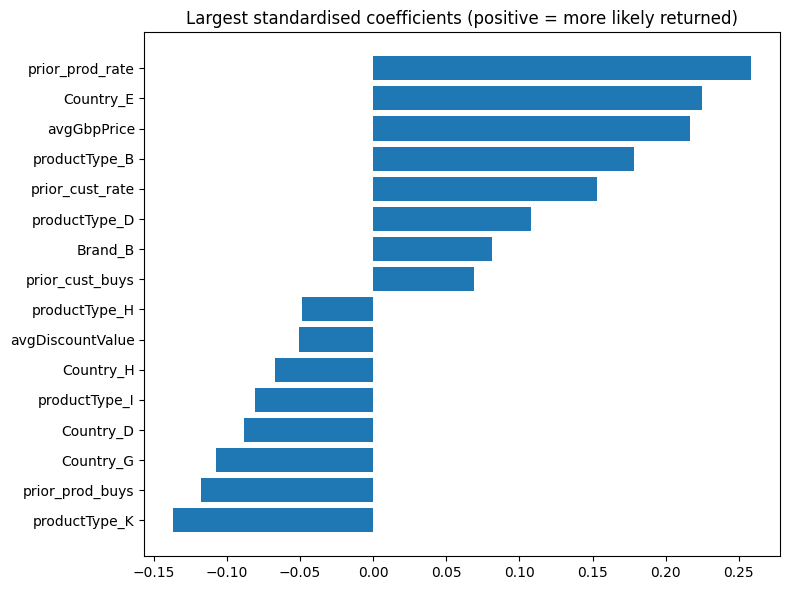

In [11]:
cols = SAFE + HIST
coef = pd.Series(model.coef_[0], index=cols).sort_values()
top = pd.concat([coef.head(8), coef.tail(8)])
plt.figure(figsize=(8, 6))
plt.barh(top.index, top.values)
plt.title("Largest standardised coefficients (positive = more likely returned)")
plt.tight_layout(); plt.show()

## Next steps (final report)
- Compare with a decision tree / random forest and logistic regression with interactions (e.g. price × discount).
- Choose the flagging threshold with a cost matrix: cost of a return (shipping, handling, depreciation) vs. cost of intervening (friction at checkout).
- Check robustness: results by country and product type.
- Limitations: anonymised categories, no size or order date, price/discount are per-variant averages, sample only includes customers with ≥1 return.